In [2]:
from helpers.load import *
from helpers.select_scenario import select_scenario
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [ ]:
"""
args_matrix = {
        "nodeXCount" : [10],
        "nodeXSpacing" : [0.2, 0.4, 0.6, 0.8, 1, 1.2, 1.4, 1.6, 1.8, 2, 4, 10],
        "nodeYCount": [1],
        "nodeYSpacing": [1],
        "nodeZCount": [1],
        "nodeZSpacing": [1],
        "uavSpeed": [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1],
        "uavZOffset": [0, -.5],
        "propagationModel": ["freshwater"],
        "stopTime": [10*60],  # seconds
        "channelWidth": ["1 --dataRatePHY=OfdmRate1_2MbpsBW1MHz", "2 --dataRatePHY=OfdmRate7_8MbpsBW2MHz"],
    }
"""

# Find all directories recursively under logs/unified
base_dir = Path(os.path.abspath('')) / 'logs' / 'unified'
scenario_folders = [p for p in base_dir.rglob('*') if p.is_dir()]
scenario_folders.sort()
# Remove all folders that still have other child folders
scenario_folders = [p for p in scenario_folders if not any([p.is_dir() for p in p.iterdir()])]

In [7]:
import concurrent.futures

# Total number of scenario folders (used for progress reporting)
total_scenarios = len(scenario_folders)

def process_scenario(args):
    i, scenario_folder = args
    # Print progress; total number of folders is referenced via total_scenarios
    print(f"Loading {i+1}/{total_scenarios}: {scenario_folder}")

    # Load the packet stats
    packet_stats_df = load_packet_logging_stats(scenario_folder)

    # Drop packets with invalid ReceiverNodeId values
    packet_stats_df = packet_stats_df[~packet_stats_df['ReceiverNodeId'].isin([-1, 4294967295])]

    # Calculate distance between source and destination nodes
    packet_stats_df['Distance'] = np.sqrt(
        (packet_stats_df['SourceNodeX'] - packet_stats_df['DestinationNodeX'])**2 +
        (packet_stats_df['SourceNodeY'] - packet_stats_df['DestinationNodeY'])**2 +
        (packet_stats_df['SourceNodeZ'] - packet_stats_df['DestinationNodeZ'])**2
    )

    # Compute the airtime
    packet_stats_df['AirTime'] = packet_stats_df['RxEndLastSeen'] - packet_stats_df['TxBeginFirstSeen']

    # Exclude packets sent and received by the same node (distance 0)
    packet_stats_df = packet_stats_df[packet_stats_df['Distance'] > 0]

    # Calculate throughput: group by distance and aggregate the data
    throughput_df = packet_stats_df[
        (packet_stats_df['SourceNodeType'] == 'STA') &
        (packet_stats_df['DestinationNodeType'] == 'AP')
    ].groupby('Distance').agg({
        'PacketSize': 'mean',
        'AirTime': 'mean',
        'PacketId': 'count'
    })

    # Convert AirTime from ns to s and compute Throughput
    throughput_df['AirTime'] = throughput_df['AirTime'] / 1e9
    throughput_df['Throughput'] = throughput_df['PacketSize'] / throughput_df['AirTime']

    return throughput_df

# Use ThreadPoolExecutor to process folders concurrently with 12 threads
with concurrent.futures.ThreadPoolExecutor(max_workers=12) as executor:
    # executor.map will pass each tuple (index, folder) to process_scenario
    throughput_stats = list(executor.map(process_scenario, enumerate(scenario_folders)))


Loading 1/624: /home/research/ns3/postprocessing/logs/unified/freshwater/nodeXCount=10_nodeXSpacing=0.2_nodeYCount=1_nodeYSpacing=1_nodeZCount=1_nodeZSpacing=1_uavSpeed=0.05_uavZOffset=0.5_propagationModel=freshwater_stopTime=600_channelWidth=1_dataRatePHY=OfdmRate1_2MbpsBW1MHz
Loading 2/624: /home/research/ns3/postprocessing/logs/unified/freshwater/nodeXCount=10_nodeXSpacing=0.2_nodeYCount=1_nodeYSpacing=1_nodeZCount=1_nodeZSpacing=1_uavSpeed=0.05_uavZOffset=0.5_propagationModel=freshwater_stopTime=600_channelWidth=2_dataRatePHY=OfdmRate7_8MbpsBW2MHz
Loading 3/624: /home/research/ns3/postprocessing/logs/unified/freshwater/nodeXCount=10_nodeXSpacing=0.2_nodeYCount=1_nodeYSpacing=1_nodeZCount=1_nodeZSpacing=1_uavSpeed=0.05_uavZOffset=0_propagationModel=freshwater_stopTime=600_channelWidth=1_dataRatePHY=OfdmRate1_2MbpsBW1MHz
Loading 4/624: /home/research/ns3/postprocessing/logs/unified/freshwater/nodeXCount=10_nodeXSpacing=0.2_nodeYCount=1_nodeYSpacing=1_nodeZCount=1_nodeZSpacing=1_uavSp

In [10]:
# Drop all throughput entries that are outside 3sd
def drop_outliers(df):
    return df[np.abs(df['Throughput'] - df['Throughput'].mean()) <= (3 * df['Throughput'].std())]

throughput_stats = [drop_outliers(df) for df in throughput_stats]

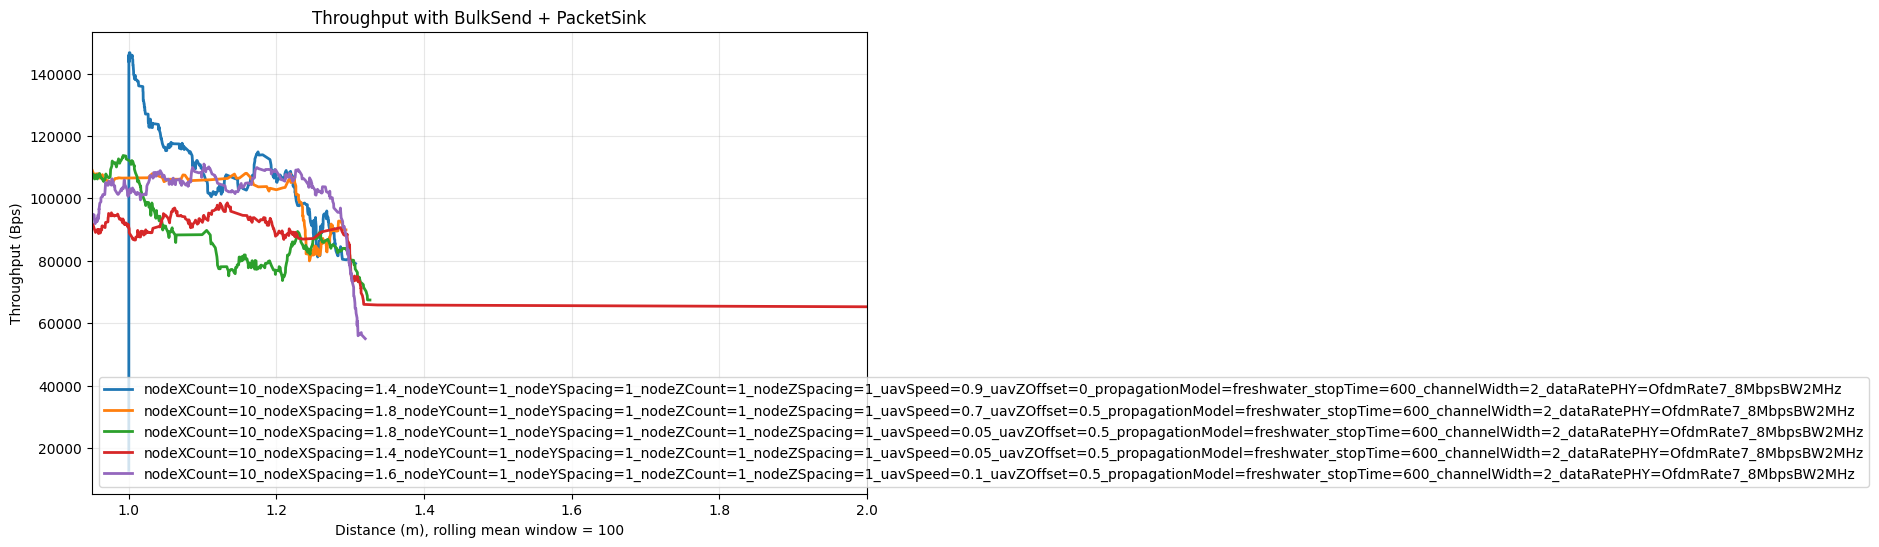

In [45]:
rolling_mean_window_size = 100
plt.figure(figsize=(10, 6))

# Get the 5 dfs with the highest mean throughput and at least 100 entries
top_5_throughput = [(scenario_folders[i], df) for i, df in enumerate(throughput_stats) if len(df) >= 500]
top_5_throughput = sorted(top_5_throughput, key=lambda x: x[1]['Throughput'].mean(), reverse=True)[:5]
    
# Plot rolling averages as solid lines
for i, df in enumerate(top_5_throughput):
    scenario_folder, df = df
    plt.plot(df.index, df['Throughput'].rolling(window=rolling_mean_window_size, min_periods=1).mean(), 
             label=scenario_folder.name, linewidth=2)

plt.xlabel(f'Distance (m), rolling mean window = {rolling_mean_window_size}')
plt.ylabel('Throughput (Bps)')
plt.title(f'Throughput with BulkSend + PacketSink')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0.95, 2)

plt.show()

In [57]:
import re
# Create a df with the mean throughput for each scenario + using ([a-zA-Z]+=[-\d.]+) as regex to extract the parameters from the folder name
parameters = ['nodeXSpacing', 'uavSpeed', 'uavZOffset', 'channelWidth']
mean_throughputs = pd.DataFrame(columns=['Throughput'] + parameters)
for i, df in enumerate(throughput_stats):
    mean_throughputs.at[i, 'Throughput'] = df['Throughput'].mean() if len(df) > 0 else 0
    
    # Extract parameters from folder name
    param_values = {}
    for param in parameters:
        match = re.search(f"{param}=([-\\d.]+)", scenario_folders[i].name)
        if match:
            # Convert to float
            param_values[param] = float(match.group(1))
            # If the parameter is uavZOffset, add - to the value
            if param == 'uavZOffset':
                param_values[param] *= -1
    
    # Set values for each parameter
    for param in parameters:
        mean_throughputs.at[i, param] = param_values[param]
    
mean_throughputs

,Throughput,nodeXSpacing,uavSpeed,uavZOffset,channelWidth
0,7644.051557,0.2,0.05,-0.5,1.0
1,37526.659061,0.2,0.05,-0.5,2.0
2,7241.919504,0.2,0.05,-0.0,1.0
3,34973.628561,0.2,0.05,-0.0,2.0
4,7544.089891,0.2,0.15,-0.5,1.0
...,...,...,...,...,...
619,94459.017433,4.0,0.9,-0.0,2.0
620,54867.236928,4.0,1.0,-0.5,1.0
621,90943.830198,4.0,1.0,-0.5,2.0
622,57840.915447,4.0,1.0,-0.0,1.0


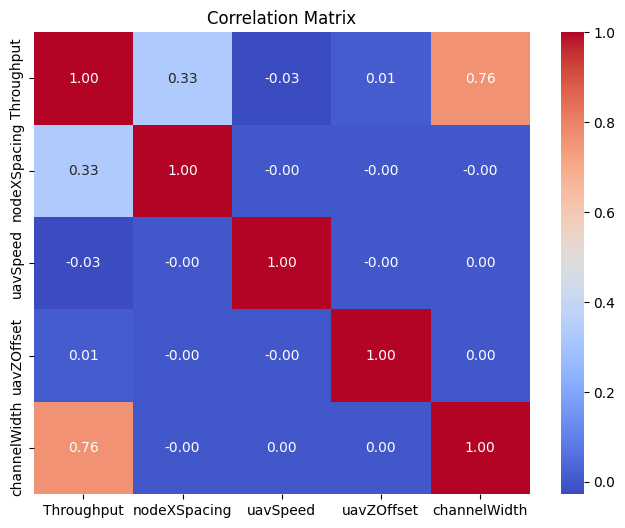

In [58]:
import seaborn as sns

corr_matrix = mean_throughputs.corr()

# Visualize the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [59]:
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

# Convert all columns to numeric types
for col in mean_throughputs.columns:
	mean_throughputs[col] = pd.to_numeric(mean_throughputs[col])

# Define independent variables and dependent variable
X = mean_throughputs[parameters]
y = mean_throughputs['Throughput']

# Standardize the predictors to compare coefficients directly
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Add constant term for the intercept
X_scaled_const = sm.add_constant(X_scaled)

# Fit the OLS regression model
model = sm.OLS(y, X_scaled_const).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             Throughput   R-squared:                       0.690
Model:                            OLS   Adj. R-squared:                  0.688
Method:                 Least Squares   F-statistic:                     345.1
Date:                Tue, 25 Mar 2025   Prob (F-statistic):          5.50e-156
Time:                        18:56:14   Log-Likelihood:                -6883.0
No. Observations:                 624   AIC:                         1.378e+04
Df Residuals:                     619   BIC:                         1.380e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         5.252e+04    600.292     87.491      0.000    5.13e+04    5.37e+04
nodeXSpacing  8956.6890    600.292     14.921      0.000    7777.832    1.01e+04
uavSpeed      -738.3423    600.292     -1.230      0.219   -1917.199     440.514
uavZOffset     257.4274    600.292      0.429      0.668    -921.429    1436.284
channelWidth  2.041e+04    600.292     33.999      0.000    1.92e+04    2.16e+04
==============================================================================
Omnibus:                      109.373   Durbin-Watson:                   0.674
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              328.830
Skew:                          -0.841   Prob(JB):                     3.94e-72
Kurtosis:                       6.134   Cond. No.                         1.00
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [60]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X, y)
importances = rf.feature_importances_
features = X.columns

importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
importance_df = importance_df.sort_values('Importance', ascending=False)
importance_df

,Feature,Importance
3,channelWidth,0.580816
0,nodeXSpacing,0.351084
1,uavSpeed,0.054273
2,uavZOffset,0.013828


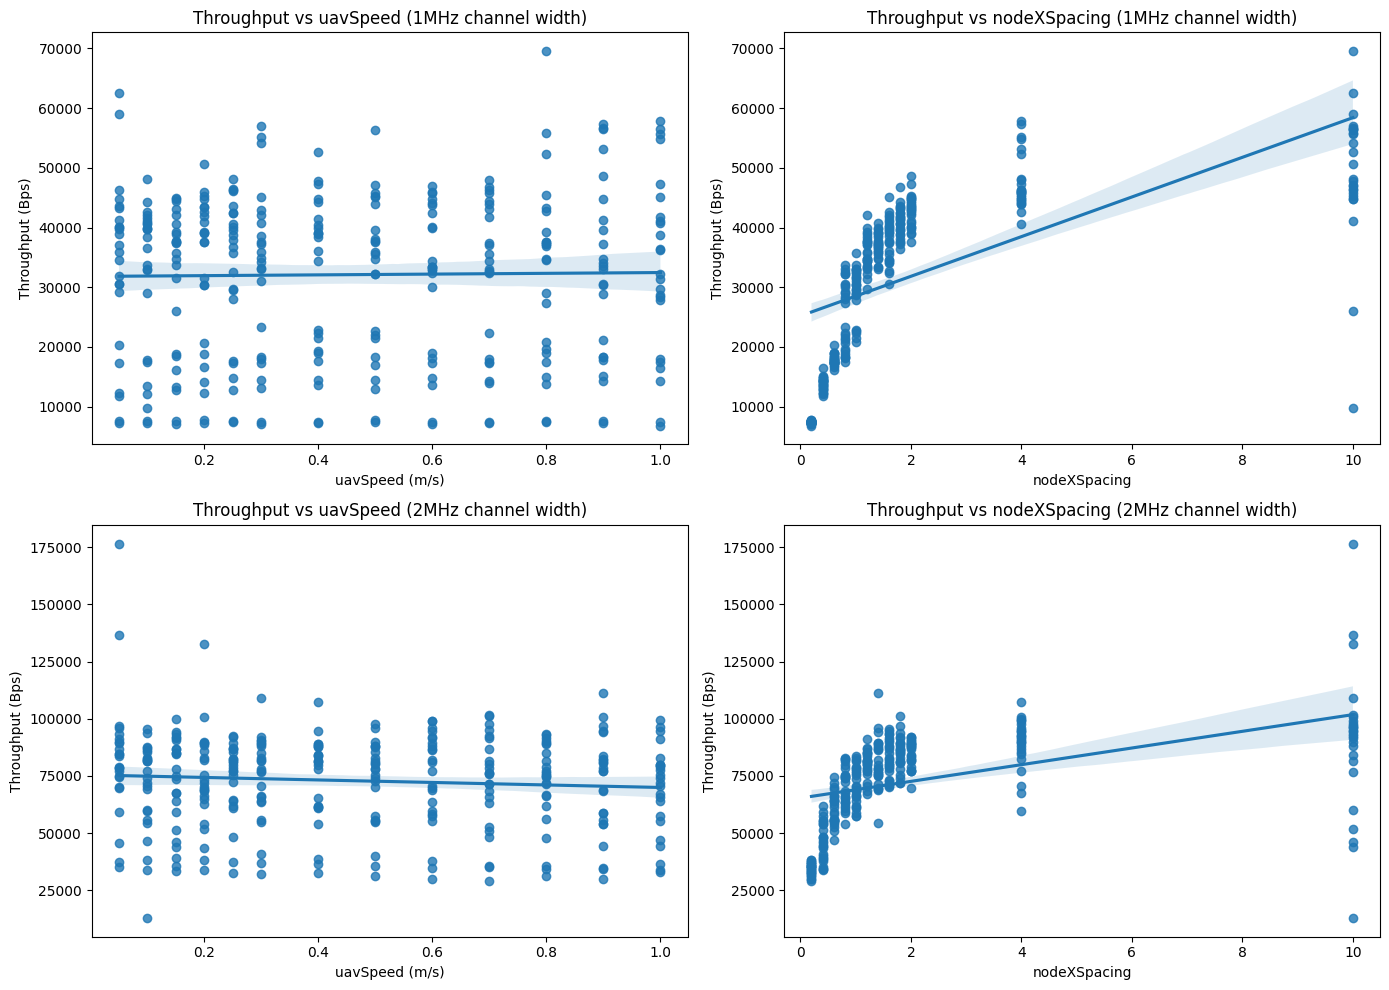

In [61]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Throughput vs uavSpeed
sns.regplot(x='uavSpeed', y='Throughput', data=mean_throughputs[mean_throughputs['channelWidth'] == 1], ax=axes[0,0])
axes[0,0].set_title("Throughput vs uavSpeed (1MHz channel width)")
axes[0,0].set_xlabel("uavSpeed (m/s)")
axes[0,0].set_ylabel("Throughput (Bps)")

# Throughput vs nodeXSpacing
sns.regplot(x='nodeXSpacing', y='Throughput', data=mean_throughputs[mean_throughputs['channelWidth'] == 1], ax=axes[0,1])
axes[0,1].set_title("Throughput vs nodeXSpacing (1MHz channel width)")
axes[0,1].set_xlabel("nodeXSpacing")
axes[0,1].set_ylabel("Throughput (Bps)")

# Throughput vs uavSpeed
sns.regplot(x='uavSpeed', y='Throughput', data=mean_throughputs[mean_throughputs['channelWidth'] == 2], ax=axes[1,0])
axes[1,0].set_title("Throughput vs uavSpeed (2MHz channel width)")
axes[1,0].set_xlabel("uavSpeed (m/s)")
axes[1,0].set_ylabel("Throughput (Bps)")

# Throughput vs nodeXSpacing
sns.regplot(x='nodeXSpacing', y='Throughput', data=mean_throughputs[mean_throughputs['channelWidth'] == 2], ax=axes[1,1])
axes[1,1].set_title("Throughput vs nodeXSpacing (2MHz channel width)")
axes[1,1].set_xlabel("nodeXSpacing")
axes[1,1].set_ylabel("Throughput (Bps)")

plt.tight_layout()
plt.show()